# Intrinsic k-means on the circle

Euclidean k-means alternates between assigning each observation to its nearest
center and replacing every center by an arithmetic mean. On a manifold, the
same idea uses geodesic distance and a Fréchet mean. For clusters
$G_1,\ldots,G_K$ on a geometry $M$, the objective is

$$
\sum_{k=1}^K \sum_{x_i\in G_k} d(x_i,\mu_k)^2,
$$

where $\mu_k$ is the Fréchet mean of cluster $G_k$.

We use $S^1\subset\mathbb R^2$ so the assignments, centers, and optimization
history can all be seen directly. This follows the Riemannian k-means pattern
in the Geomstats tutorials, but keeps the complete algorithm visible.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from geojax.geometry import Sphere

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

M = Sphere(size=2)
true_angles = jnp.array([-2.2, 0.15, 2.05])
key = jax.random.key(17)
keys = jax.random.split(key, len(true_angles))

cluster_angles = [
    angle + 0.22 * jax.random.normal(subkey, shape=(55,))
    for angle, subkey in zip(true_angles, keys)
]
angles = jnp.concatenate(cluster_angles)
data = jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)

print("number of observations:", data.shape[0])
print("all points lie on S^1:", bool(jnp.all(M.belongs(data))))

number of observations: 165
all points lie on S^1: True


all points lie on S^1: True


## Lloyd updates with manifold primitives

The assignment step needs only `dist`. For the center update, a few Karcher
steps average logarithm vectors in the current tangent space and return to the
circle with the exponential map:

$$
\mu \leftarrow \operatorname{Exp}_{\mu}
\left(\frac{1}{|G|}\sum_{x\in G}\operatorname{Log}_{\mu}(x)\right).
$$

In [2]:
def frechet_mean(points, initial, steps=8):
    center = initial
    for _ in range(steps):
        logs = jax.vmap(lambda point: M.log(center, point))(points)
        center = M.exp(center, jnp.mean(logs, axis=0))
    return center


def distances_to_centers(points, centers):
    return jax.vmap(
        lambda point: jax.vmap(lambda center: M.dist(point, center))(centers)
    )(points)


centers = data[jnp.array([8, 68, 128])]
objective_history = []

for _ in range(12):
    distances = distances_to_centers(data, centers)
    labels = jnp.argmin(distances, axis=1)
    objective_history.append(float(jnp.mean(jnp.min(distances, axis=1) ** 2)))
    centers = jnp.stack([
        frechet_mean(data[labels == cluster], centers[cluster])
        for cluster in range(3)
    ])

distances = distances_to_centers(data, centers)
labels = jnp.argmin(distances, axis=1)
objective_history.append(float(jnp.mean(jnp.min(distances, axis=1) ** 2)))

estimated_angles = jnp.arctan2(centers[:, 1], centers[:, 0])
print("estimated center angles:", jnp.sort(estimated_angles))
print("final mean squared distance:", objective_history[-1])
print("cluster sizes:", jnp.bincount(labels, length=3))

estimated center angles: [-2.24023426  0.15438317  2.06168575]
final mean squared distance: 0.0534087054178049
cluster sizes: [55 55 55]


cluster sizes: [55 55 55]


## Visual report

The left panel shows the observations without labels. The middle panel shows
the intrinsic assignments and estimated centers. Radial jitter is used only to
make overlapping observations legible; every computation used the points on
the unit circle.

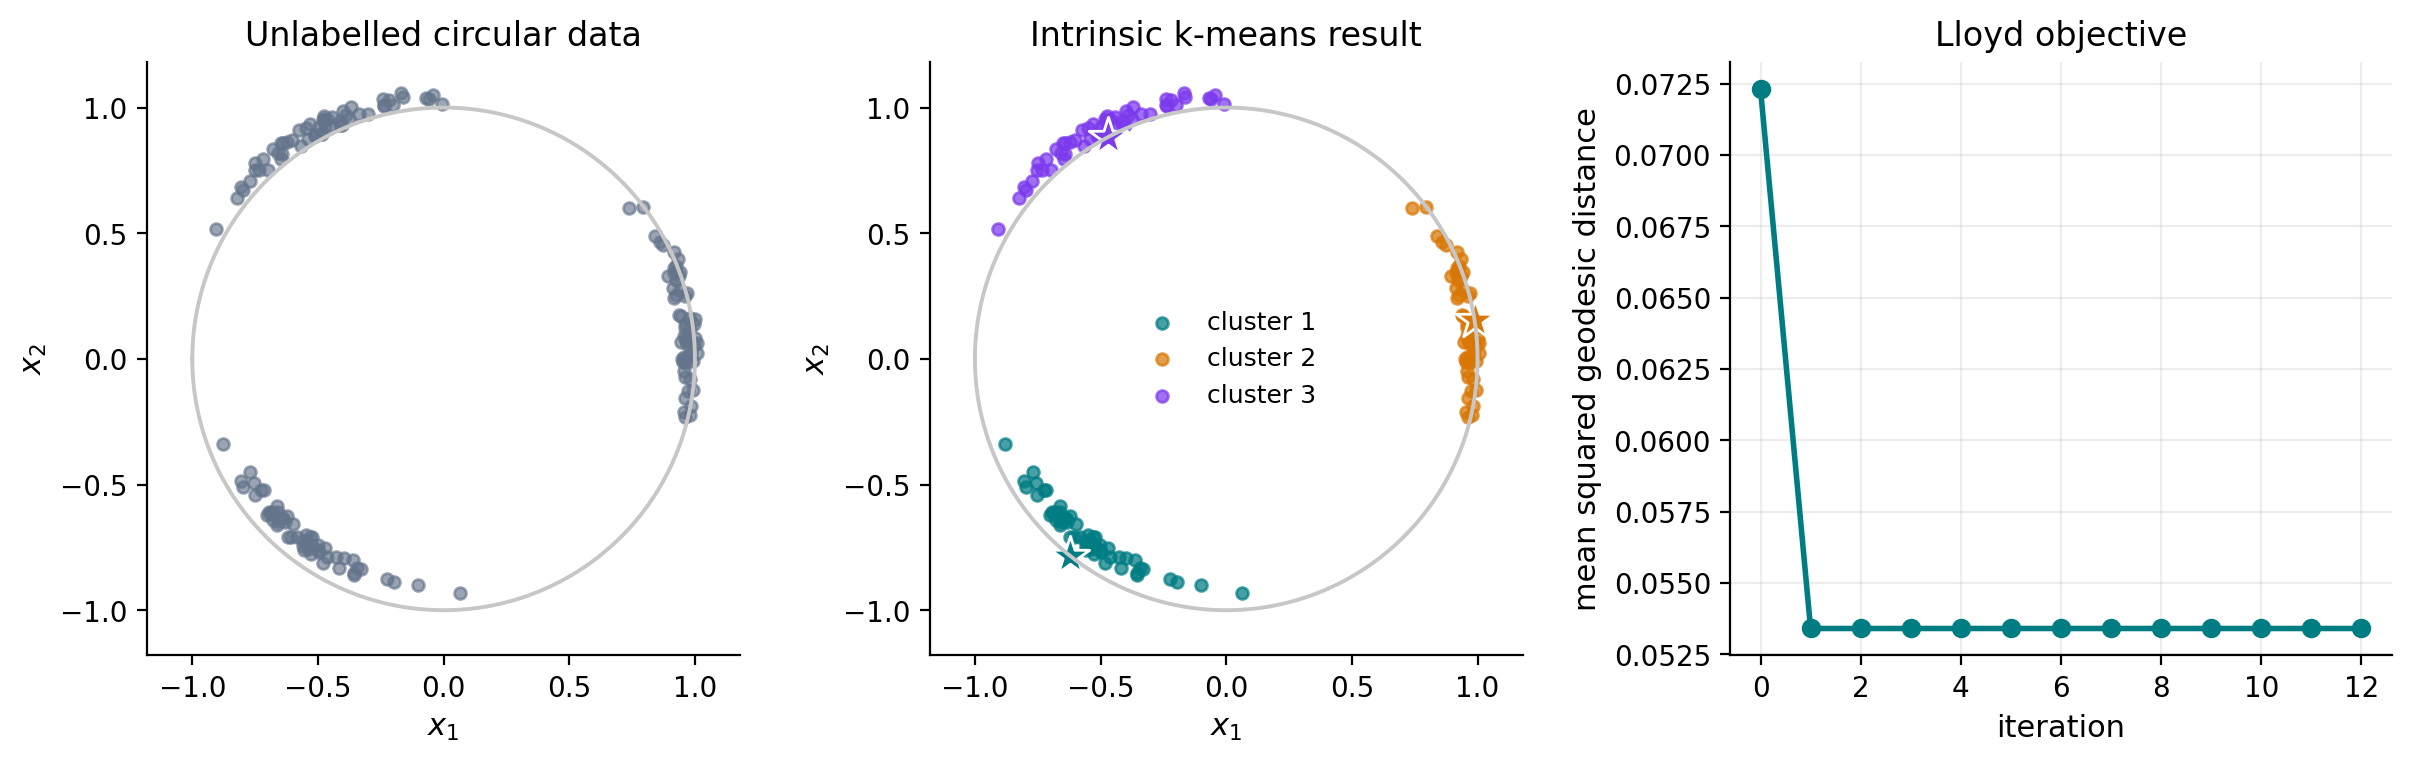

In [3]:
palette = np.array(["#007C83", "#D97706", "#7C3AED"])
theta_grid = np.linspace(-np.pi, np.pi, 500)
circle = np.column_stack([np.cos(theta_grid), np.sin(theta_grid)])
jitter = 0.88 + 0.20 * np.linspace(0.0, 1.0, len(data))
display_points = np.asarray(data) * jitter[:, None]

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.7), constrained_layout=True)

for ax in axes[:2]:
    ax.plot(circle[:, 0], circle[:, 1], color="0.78", linewidth=1.4)
    ax.set_aspect("equal")
    ax.set(xlim=(-1.18, 1.18), ylim=(-1.18, 1.18), xlabel="$x_1$", ylabel="$x_2$")

axes[0].scatter(display_points[:, 0], display_points[:, 1], s=18, color="#64748B", alpha=0.65)
axes[0].set_title("Unlabelled circular data")

for cluster, color in enumerate(palette):
    mask = np.asarray(labels) == cluster
    axes[1].scatter(
        display_points[mask, 0], display_points[mask, 1],
        s=18, color=color, alpha=0.72, label=f"cluster {cluster + 1}",
    )
    center = np.asarray(centers[cluster])
    axes[1].scatter(*center, marker="*", s=210, color=color, edgecolor="white", linewidth=1.0)
axes[1].set_title("Intrinsic k-means result")
axes[1].legend(frameon=False, fontsize=9, loc="center")

axes[2].plot(objective_history, marker="o", color="#007C83", linewidth=2)
axes[2].set(
    title="Lloyd objective",
    xlabel="iteration",
    ylabel="mean squared geodesic distance",
)
axes[2].grid(alpha=0.22)

plt.show()

The centers lie on the manifold by construction, including when a cluster
crosses the $-\pi/\pi$ coordinate boundary. Replacing the logarithm update by an
ordinary arithmetic mean of angles would not have that invariance.

## What to try next

- Increase the cluster spread until points approach the cut locus.
- Replace `Sphere(size=2)` with `Sphere(size=3)` and draw clusters on $S^2$.
- Use several random initializations and retain the smallest final objective.